# Step 1 :  Import Library and Dataset

In [36]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [37]:
# Read the data in
employee = pd.read_csv(r"Bank_Loan.csv")

In [38]:
employee.head(5)

,Loan_ID,Age,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,LoanAmount,Previous_Loan_Taken,Cibil_Score,Property_Area,Customer_Bandwith,Tenure,Loan_Status
0,LP001002,43,Male,No,3,Yes,No,54005,334113,Yes,668,Urban,Good,43,No
1,LP001003,57,Male,Yes,2,Yes,No,28817,736026,Yes,684,Rural,Good,13,Yes
2,LP001005,25,Male,Yes,3,Yes,Yes,99939,712432,Yes,788,Urban,Good,10,No
3,LP001006,44,Male,Yes,1,No,No,38470,267161,Yes,888,Urban,Good,9,No
4,LP001008,58,Male,No,1,Yes,No,28991,402474,Yes,703,Urban,Good,11,No


# Step 2 : Data Pre-Processing

### Removing Irrelavent Variable

In [39]:
employee = employee.drop(['Loan_ID'],axis=1)
employee.columns

Index(['Age', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'LoanAmount', 'Previous_Loan_Taken', 'Cibil_Score',
       'Property_Area', 'Customer_Bandwith', 'Tenure', 'Loan_Status'],
      dtype='str')

### Univariate Analysis

In [40]:
employee.info()

<class 'pandas.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Age                  981 non-null    int64
 1   Gender               981 non-null    str  
 2   Married              981 non-null    str  
 3   Dependents           981 non-null    int64
 4   Education            981 non-null    str  
 5   Self_Employed        981 non-null    str  
 6   ApplicantIncome      981 non-null    int64
 7   LoanAmount           981 non-null    int64
 8   Previous_Loan_Taken  981 non-null    str  
 9   Cibil_Score          981 non-null    int64
 10  Property_Area        981 non-null    str  
 11  Customer_Bandwith    981 non-null    str  
 12  Tenure               981 non-null    int64
 13  Loan_Status          981 non-null    str  
dtypes: int64(6), str(8)
memory usage: 107.4 KB


### Outlier

<Axes: >

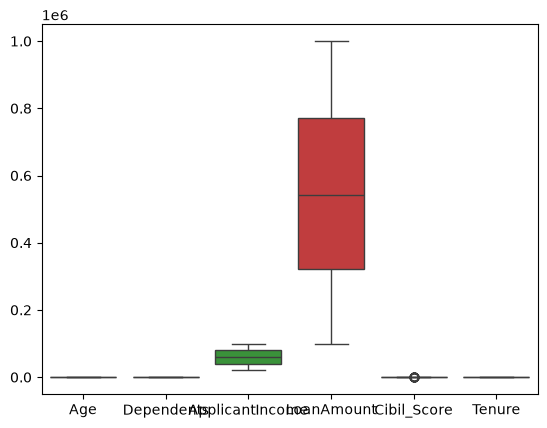

In [41]:
import seaborn as sns
sns.boxplot(data=employee)

### Checking Missing Value

In [42]:
employee.isna().sum()  ## is = check & as = convert

Age                    0
Gender                 0
Married                0
Dependents             0
Education              0
Self_Employed          0
ApplicantIncome        0
LoanAmount             0
Previous_Loan_Taken    0
Cibil_Score            0
Property_Area          0
Customer_Bandwith      0
Tenure                 0
Loan_Status            0
dtype: int64

# Bad Rate Analysis

In [43]:
import plotly.express as px

fig = px.pie(employee,names='Loan_Status',color='Loan_Status',
             color_discrete_map={'Yes':'green',
                                 'No':'red'})
fig.show()

### Taking subset data of Number 

In [44]:
# #Employee Numeric columns
employee_num = employee.select_dtypes(include=[np.number])
employee_num.head(3)

,Age,Dependents,ApplicantIncome,LoanAmount,Cibil_Score,Tenure
0,43,3,54005,334113,668,43
1,57,2,28817,736026,684,13
2,25,3,99939,712432,788,10


### Taking subset data of Category 

In [45]:
employee_dummies = employee.select_dtypes(include=['object'])
employee_dummies.head(3)

,Gender,Married,Education,Self_Employed,Previous_Loan_Taken,Property_Area,Customer_Bandwith,Loan_Status
0,Male,No,Yes,No,Yes,Urban,Good,No
1,Male,Yes,Yes,No,Yes,Rural,Good,Yes
2,Male,Yes,Yes,Yes,Yes,Urban,Good,No


### Converting Quality Variable to Number

In [46]:
from sklearn.preprocessing import LabelEncoder

employee_dummies = employee_dummies.apply(LabelEncoder().fit_transform)
employee_dummies.head(3)

,Gender,Married,Education,Self_Employed,Previous_Loan_Taken,Property_Area,Customer_Bandwith,Loan_Status
0,1,0,1,0,1,2,1,0
1,1,1,1,0,1,0,1,1
2,1,1,1,1,1,2,1,0


### Combine to Dataset

In [47]:
employee_combined = pd.concat([employee_num, employee_dummies],axis=1)
employee_combined.head()

,Age,Dependents,ApplicantIncome,LoanAmount,Cibil_Score,Tenure,Gender,Married,Education,Self_Employed,Previous_Loan_Taken,Property_Area,Customer_Bandwith,Loan_Status
0,43,3,54005,334113,668,43,1,0,1,0,1,2,1,0
1,57,2,28817,736026,684,13,1,1,1,0,1,0,1,1
2,25,3,99939,712432,788,10,1,1,1,1,1,2,1,0
3,44,1,38470,267161,888,9,1,1,0,0,1,2,1,0
4,58,1,28991,402474,703,11,1,0,1,0,1,2,1,0


#### EDA Completed

# Step 3: Data Partition

In [48]:
from sklearn.model_selection import train_test_split

x = employee_combined.drop(['Loan_Status'],axis=1)
y = employee_combined[['Loan_Status']]

X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=231)

# Step 4: Model Building

### Model Improvement by Pruning Method ( Cut Tree)

In [49]:
from sklearn import tree

dt2 = tree.DecisionTreeClassifier(criterion='gini',  #splitter
                                 min_samples_split=300, #parent
                                 min_samples_leaf=50, ## child
                                 max_depth=4)  #branches

dt2.fit(X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",300
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [50]:
train = pd.concat([y_train,X_train],axis=1)
train.head()

,Loan_Status,Age,Dependents,ApplicantIncome,LoanAmount,Cibil_Score,Tenure,Gender,Married,Education,Self_Employed,Previous_Loan_Taken,Property_Area,Customer_Bandwith
384,1,41,1,40507,826347,386,13,1,1,1,0,1,2,0
452,1,58,1,66490,478724,743,42,1,1,1,0,0,0,1
441,0,51,1,34043,989778,689,25,1,1,1,0,1,0,1
300,1,55,3,85756,837981,809,21,1,1,0,0,0,2,1
456,0,24,3,36259,916353,660,32,1,1,1,0,1,2,1


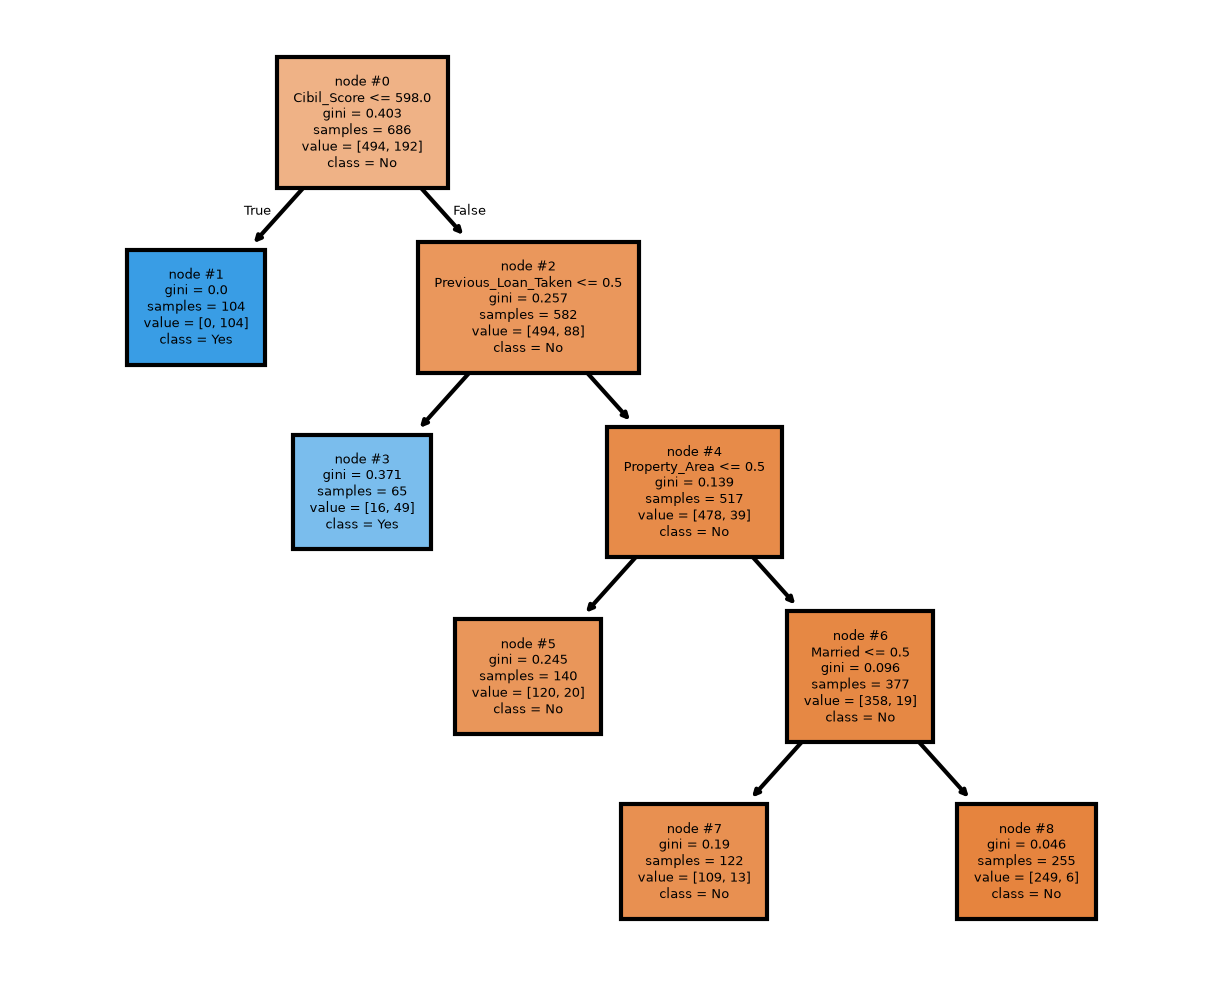

In [51]:
from sklearn import tree
import matplotlib.pyplot as plt

independent_variable = list(train.columns[1:])
churn=['No', 'Yes']  # array
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (5,4), dpi=300)
tree.plot_tree(dt2,  # Model 
               feature_names = independent_variable,  # column name
               class_names = churn, # Yes , No
               filled = True, # colour
               node_ids = True, # node number
               fontsize=3); # 

### Strategy & Prediction
* Contract = Month-to-Month & Monthly Charges > 68 & Tenure <= 15.5 

In [52]:
train['Predicted'] = dt2.predict(X_train)  # MODEL = dt2
train.head()

,Loan_Status,Age,Dependents,ApplicantIncome,LoanAmount,Cibil_Score,Tenure,Gender,Married,Education,Self_Employed,Previous_Loan_Taken,Property_Area,Customer_Bandwith,Predicted
384,1,41,1,40507,826347,386,13,1,1,1,0,1,2,0,1
452,1,58,1,66490,478724,743,42,1,1,1,0,0,0,1,1
441,0,51,1,34043,989778,689,25,1,1,1,0,1,0,1,0
300,1,55,3,85756,837981,809,21,1,1,0,0,0,2,1,1
456,0,24,3,36259,916353,660,32,1,1,1,0,1,2,1,0


In [53]:
from sklearn.metrics import classification_report
print(classification_report(train['Loan_Status'], train['Predicted']))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95       494
           1       0.91      0.80      0.85       192

    accuracy                           0.92       686
   macro avg       0.91      0.88      0.90       686
weighted avg       0.92      0.92      0.92       686



# Step 8 : Predictions on Test Dataset

In [54]:
test=pd.concat([X_test,y_test],axis=1)
test['Predicted'] = dt2.predict(X_test)  # Model = dt2
test.head()

,Age,Dependents,ApplicantIncome,LoanAmount,Cibil_Score,Tenure,Gender,Married,Education,Self_Employed,Previous_Loan_Taken,Property_Area,Customer_Bandwith,Loan_Status,Predicted
360,36,5,85231,289078,554,26,0,0,1,0,1,1,2,1,1
824,26,2,31340,511486,723,43,0,0,1,0,1,2,1,0,0
137,54,2,77458,923087,677,46,1,1,1,1,1,2,1,0,0
363,57,1,48546,216341,777,45,1,1,1,0,1,2,1,0,0
763,31,3,52153,124191,645,6,1,0,1,0,1,2,2,0,0


# Step 9 : Model Performance Metrics on Test data 

In [55]:
from sklearn.metrics import classification_report
print(classification_report(test['Loan_Status'], test['Predicted']))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95       218
           1       0.94      0.78      0.85        77

    accuracy                           0.93       295
   macro avg       0.93      0.88      0.90       295
weighted avg       0.93      0.93      0.93       295



# Finished

# Model Export

In [56]:
import sklearn
sklearn.__version__

'1.9.0'

In [57]:
import pickle

pickle.dump(dt2, open(r"build.pkl",'wb')) # Model Name = dt2

In [58]:
X_train.shape

(686, 13)

In [59]:
X_train.head()

,Age,Dependents,ApplicantIncome,LoanAmount,Cibil_Score,Tenure,Gender,Married,Education,Self_Employed,Previous_Loan_Taken,Property_Area,Customer_Bandwith
384,41,1,40507,826347,386,13,1,1,1,0,1,2,0
452,58,1,66490,478724,743,42,1,1,1,0,0,0,1
441,51,1,34043,989778,689,25,1,1,1,0,1,0,1
300,55,3,85756,837981,809,21,1,1,0,0,0,2,1
456,24,3,36259,916353,660,32,1,1,1,0,1,2,1


In [60]:
employee.Property_Area.value_counts()

Property_Area
Semiurban    349
Urban        342
Rural        290
Name: count, dtype: int64

In [61]:
X_train.head()

,Age,Dependents,ApplicantIncome,LoanAmount,Cibil_Score,Tenure,Gender,Married,Education,Self_Employed,Previous_Loan_Taken,Property_Area,Customer_Bandwith
384,41,1,40507,826347,386,13,1,1,1,0,1,2,0
452,58,1,66490,478724,743,42,1,1,1,0,0,0,1
441,51,1,34043,989778,689,25,1,1,1,0,1,0,1
300,55,3,85756,837981,809,21,1,1,0,0,0,2,1
456,24,3,36259,916353,660,32,1,1,1,0,1,2,1


In [62]:
X_train.columns

Index(['Age', 'Dependents', 'ApplicantIncome', 'LoanAmount', 'Cibil_Score',
       'Tenure', 'Gender', 'Married', 'Education', 'Self_Employed',
       'Previous_Loan_Taken', 'Property_Area', 'Customer_Bandwith'],
      dtype='str')

In [63]:
a = [np.array(X_train.iloc[0,:])]
aa = pd.DataFrame(a,columns=X_train.columns)
aa

,Age,Dependents,ApplicantIncome,LoanAmount,Cibil_Score,Tenure,Gender,Married,Education,Self_Employed,Previous_Loan_Taken,Property_Area,Customer_Bandwith
0,41,1,40507,826347,386,13,1,1,1,0,1,2,0


In [64]:
dt2.predict(aa)

array([1])